ПІДГОТОВКА ДАНИХ

Розмір датасету: (55500, 15)

Перші 5 рядків:
            Name  Age  Gender Blood Type Medical Condition Date of Admission  \
0  Bobby JacksOn   30    Male         B-            Cancer        2024-01-31   
1   LesLie TErRy   62    Male         A+           Obesity        2019-08-20   
2    DaNnY sMitH   76  Female         A-           Obesity        2022-09-22   
3   andrEw waTtS   28  Female         O+          Diabetes        2020-11-18   
4  adrIENNE bEll   43  Female        AB+            Cancer        2022-09-19   

             Doctor                    Hospital Insurance Provider  \
0     Matthew Smith             Sons and Miller         Blue Cross   
1   Samantha Davies                     Kim Inc           Medicare   
2  Tiffany Mitchell                    Cook PLC              Aetna   
3       Kevin Wells  Hernandez Rogers and Vang,           Medicare   
4    Kathleen Hanna                 White-White              Aetna   

   Billing Amount  Room Number Adm

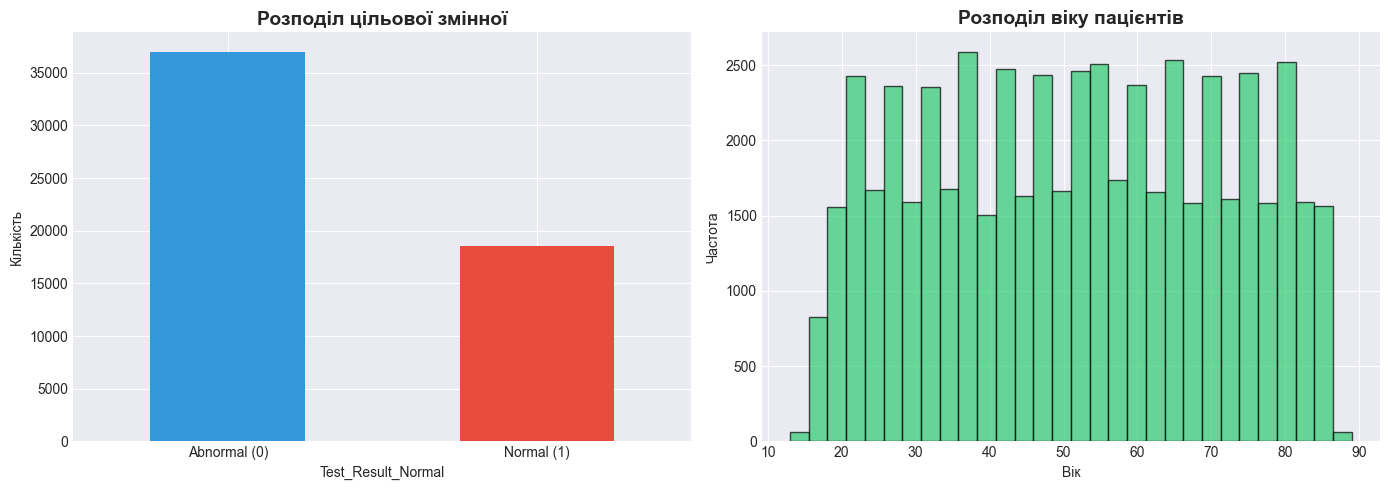

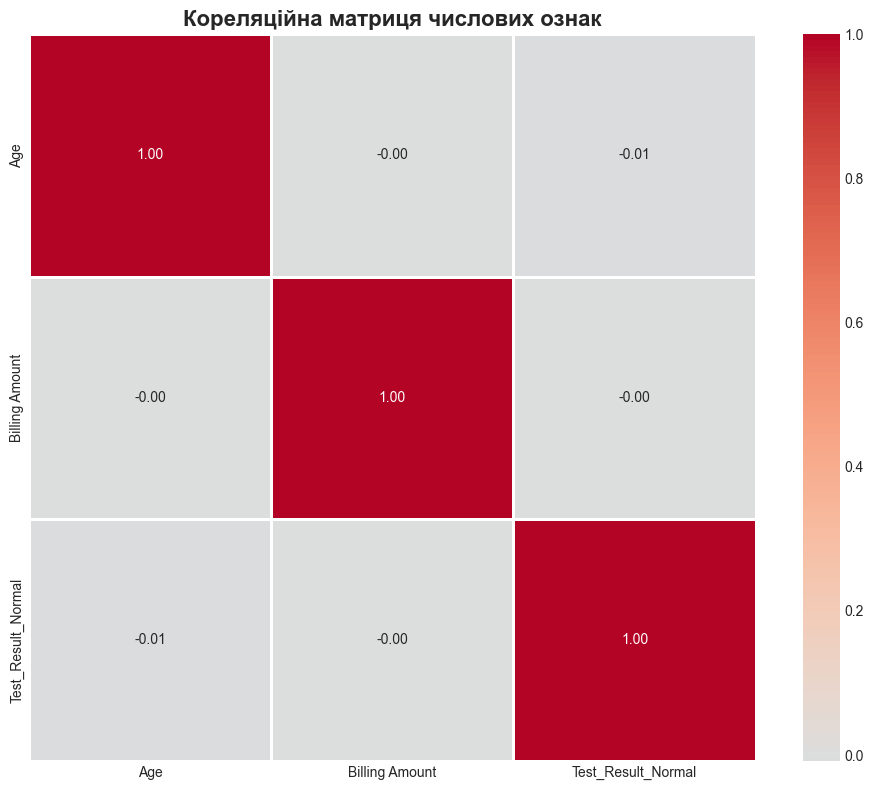


РОЗДІЛЕННЯ ТА НОРМАЛІЗАЦІЯ ДАНИХ

Розміри наборів:
Train: (33300, 25), Val: (11100, 25), Test: (11100, 25)

Розподіл класів:
Train: [22189 11111]
Val: [7397 3703]
Test: [7397 3703]

МОДЕЛЬ 1: SGD

НАВЧАННЯ: SGD
Epoch   0: Train Loss = 0.8907, Val Loss = 0.8865
Epoch  10: Train Loss = 0.8503, Val Loss = 0.8356

Рання зупинка на епосі 19

Найкраща модель: Epoch 4, Val Loss = 0.7384

МОДЕЛЬ 2: Mini-batch

НАВЧАННЯ: Mini-batch (batch_size=32)
Epoch   0: Train Loss = 0.6436, Val Loss = 0.6445
Epoch  10: Train Loss = 0.6402, Val Loss = 0.6411
Epoch  20: Train Loss = 0.6408, Val Loss = 0.6411
Epoch  30: Train Loss = 0.6439, Val Loss = 0.6439

Рання зупинка на епосі 39

Найкраща модель: Epoch 24, Val Loss = 0.6382

МОДЕЛЬ 3: Mini-batch + L2

НАВЧАННЯ: Mini-batch (batch_size=32), Regularization: L2 (λ=0.01)
Epoch   0: Train Loss = 0.6406, Val Loss = 0.6419
Epoch  10: Train Loss = 0.6417, Val Loss = 0.6405
Epoch  20: Train Loss = 0.6411, Val Loss = 0.6388

Рання зупинка на епосі 20

Найкраща мо

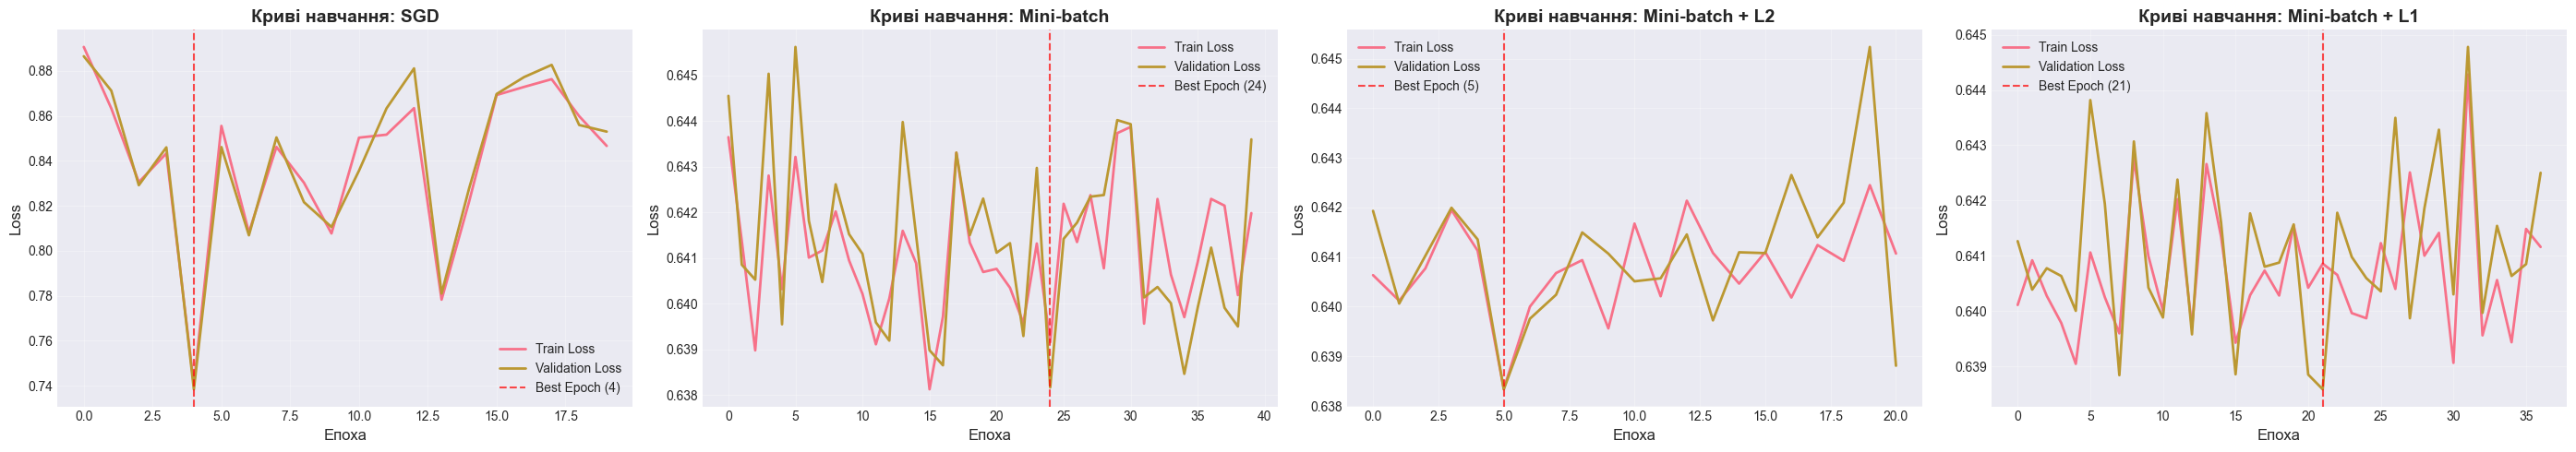


ОЦІНКА МОДЕЛІ: SGD

Confusion Matrix:
[[6712  685]
 [3366  337]]

Метрики:
Accuracy:  0.6350
Precision: 0.3297
Recall:    0.0910
F1-score:  0.1426


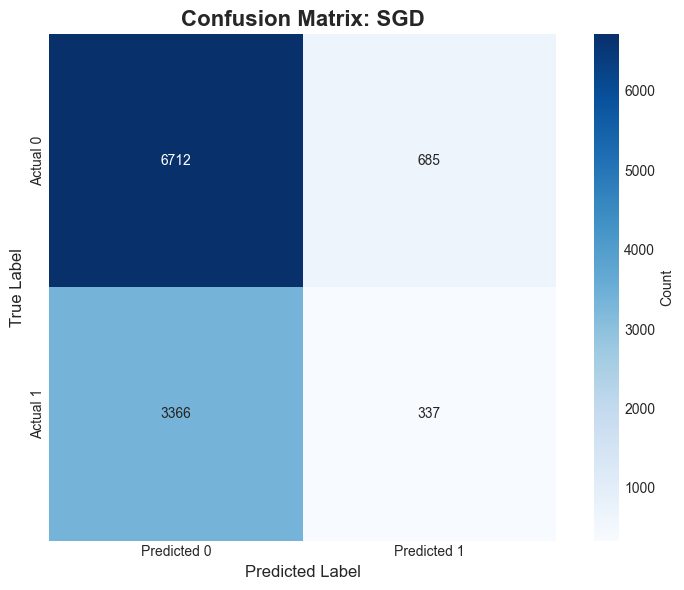


ОЦІНКА МОДЕЛІ: Mini-batch

Confusion Matrix:
[[7397    0]
 [3703    0]]

Метрики:
Accuracy:  0.6664
Precision: 0.0000
Recall:    0.0000
F1-score:  0.0000


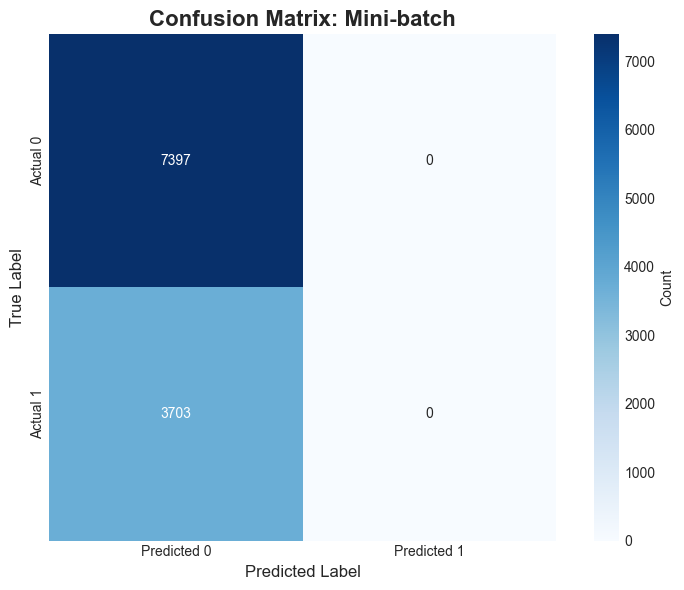


ОЦІНКА МОДЕЛІ: Mini-batch + L2

Confusion Matrix:
[[7397    0]
 [3703    0]]

Метрики:
Accuracy:  0.6664
Precision: 0.0000
Recall:    0.0000
F1-score:  0.0000


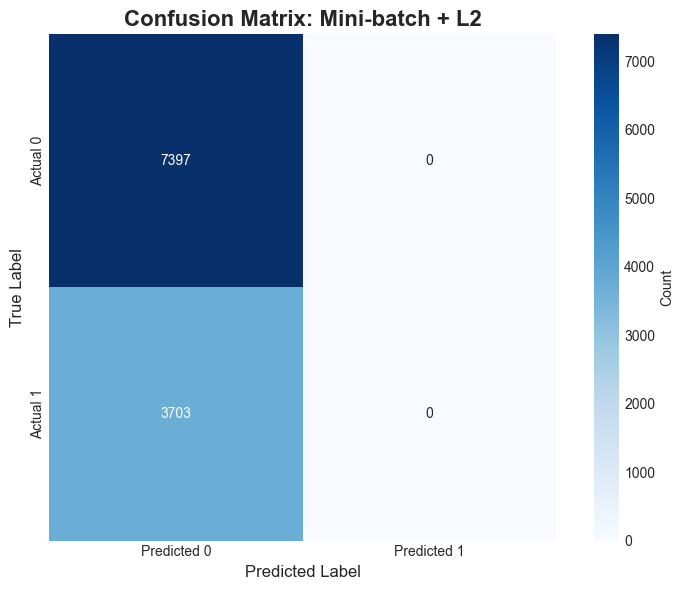


ОЦІНКА МОДЕЛІ: Mini-batch + L1

Confusion Matrix:
[[7397    0]
 [3703    0]]

Метрики:
Accuracy:  0.6664
Precision: 0.0000
Recall:    0.0000
F1-score:  0.0000


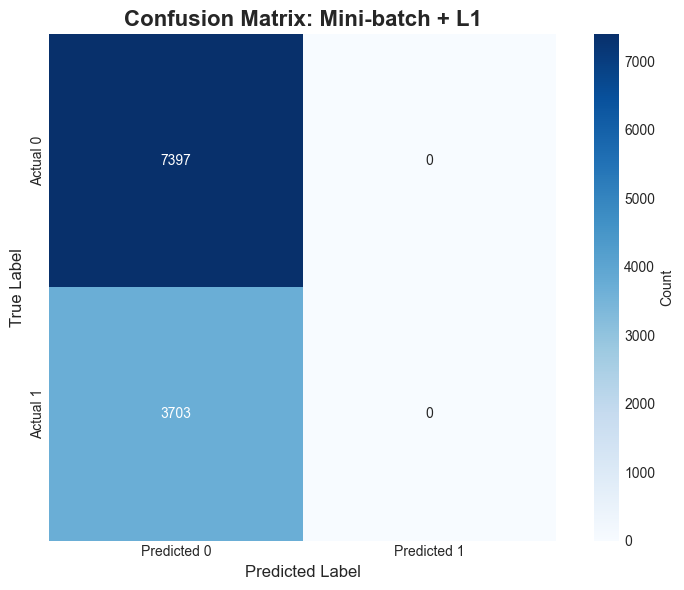


ПОРІВНЯЛЬНА ТАБЛИЦЯ МЕТРИК
                 Accuracy  Precision    Recall  F1-score
SGD              0.635045   0.329746  0.091007  0.142646
Mini-batch       0.666396   0.000000  0.000000  0.000000
Mini-batch + L2  0.666396   0.000000  0.000000  0.000000
Mini-batch + L1  0.666396   0.000000  0.000000  0.000000


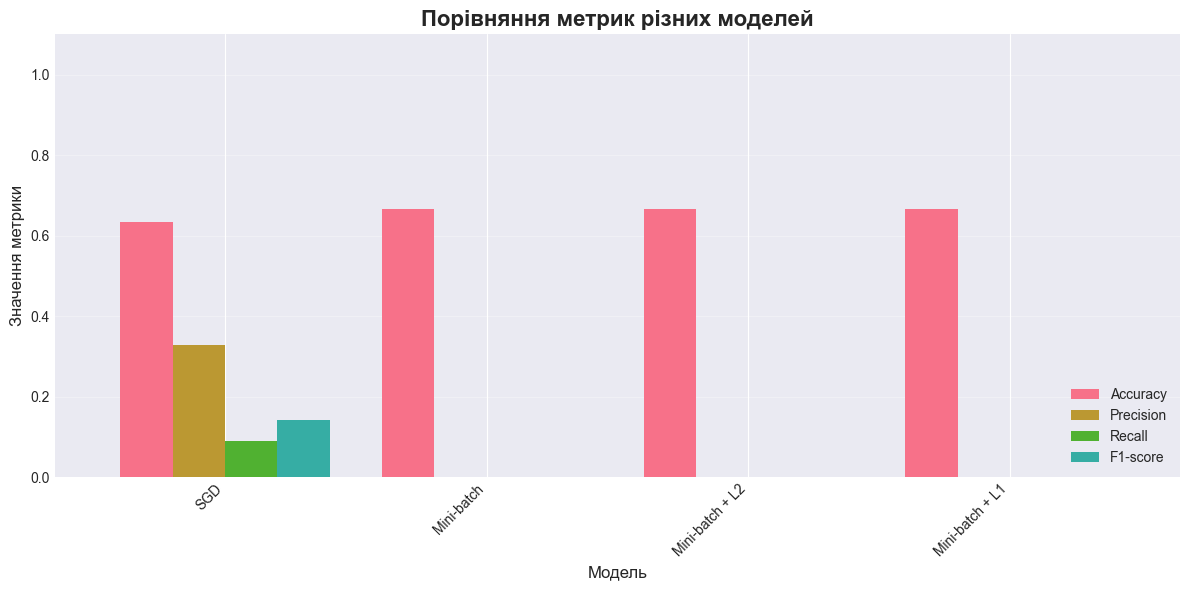


ВИСНОВКИ

    1. SGD vs Mini-batch:
       - Mini-batch показує більш стабільну збіжність завдяки усередненню градієнтів
       - SGD може мати більші коливання втрат через оновлення на кожному прикладі
    
    2. Регуляризація:
       - L2 допомагає зменшити перенавчання, обмежуючи величину ваг
       - L1 може призвести до розрідженості (sparsity) ваг
    
    3. Рання зупинка:
       - Допомагає уникнути перенавчання, зупиняючи навчання при погіршенні валідації
    
    4. Швидкість навчання:
       - Критичний гіперпараметр, що впливає на збіжність
       - Потребує налаштування для оптимальної продуктивності
    


In [1]:
# Логістична регресія з нуля для класифікації медичних даних
# Реалізація SGD та Mini-batch градієнтного спуску з регуляризацією

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Налаштування для кращої візуалізації
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================================
# 1. ПІДГОТОВКА ДАНИХ
# ============================================================================

def load_and_prepare_data(filepath):
    """
    Завантаження та підготовка даних для логістичної регресії
    """
    print("=" * 80)
    print("ПІДГОТОВКА ДАНИХ")
    print("=" * 80)
    
    # Завантаження даних
    df = pd.read_csv(filepath)
    print(f"\nРозмір датасету: {df.shape}")
    print(f"\nПерші 5 рядків:\n{df.head()}")
    
    # Створення цільової змінної
    df['Test_Result_Normal'] = (df['Test Results'] == 'Normal').astype(int)
    print(f"\nРозподіл цільової змінної:")
    print(df['Test_Result_Normal'].value_counts())
    
    # Видалення непотрібних колонок
    columns_to_drop = ['Name', 'Date of Admission', 'Doctor', 'Hospital', 
                       'Room Number', 'Discharge Date', 'Test Results']
    df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])
    
    # One-hot encoding для категоріальних ознак
    categorical_cols = ['Gender', 'Blood Type', 'Medical Condition', 
                        'Insurance Provider', 'Admission Type', 'Medication']
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    
    print(f"\nРозмір після кодування: {df_encoded.shape}")
    
    return df_encoded

def analyze_data(df):
    """
    Аналіз даних: розподіли, кореляції, візуалізації
    """
    print("\n" + "=" * 80)
    print("АНАЛІЗ ДАНИХ")
    print("=" * 80)
    
    # Статистика
    print("\nОписова статистика:")
    print(df.describe())
    
    # Візуалізація розподілу цільової змінної
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Розподіл цільової змінної
    df['Test_Result_Normal'].value_counts().plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
    axes[0].set_title('Розподіл цільової змінної', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Test_Result_Normal')
    axes[0].set_ylabel('Кількість')
    axes[0].set_xticklabels(['Abnormal (0)', 'Normal (1)'], rotation=0)
    
    # Розподіл віку
    axes[1].hist(df['Age'], bins=30, color='#2ecc71', alpha=0.7, edgecolor='black')
    axes[1].set_title('Розподіл віку пацієнтів', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Вік')
    axes[1].set_ylabel('Частота')
    
    plt.tight_layout()
    plt.show()
    
    # Кореляційна матриця для числових ознак
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    corr_matrix = df[numeric_cols].corr()
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=1)
    plt.title('Кореляційна матриця числових ознак', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return corr_matrix

def split_and_normalize_data(df, target_col='Test_Result_Normal', random_state=42):
    """
    Розділення на train/val/test та нормалізація
    """
    print("\n" + "=" * 80)
    print("РОЗДІЛЕННЯ ТА НОРМАЛІЗАЦІЯ ДАНИХ")
    print("=" * 80)
    
    # Розділення на ознаки та цільову змінну
    X = df.drop(columns=[target_col]).values
    y = df[target_col].values
    
    # Розділення: 60% train, 20% val, 20% test
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.25, random_state=random_state, stratify=y_temp
    )
    
    # Нормалізація
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)
    
    print(f"\nРозміри наборів:")
    print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
    print(f"\nРозподіл класів:")
    print(f"Train: {np.bincount(y_train)}")
    print(f"Val: {np.bincount(y_val)}")
    print(f"Test: {np.bincount(y_test)}")
    
    return X_train, X_val, X_test, y_train, y_val, y_test

# ============================================================================
# 2. РЕАЛІЗАЦІЯ ЛОГІСТИЧНОЇ РЕГРЕСІЇ
# ============================================================================

class LogisticRegression:
    """
    Логістична регресія з SGD та Mini-batch градієнтним спуском
    """
    
    def __init__(self, learning_rate=0.01, max_epochs=100, batch_size=32, 
                 regularization=None, reg_lambda=0.01, patience=10, verbose=True):
        """
        Параметри:
        - learning_rate: швидкість навчання
        - max_epochs: максимальна кількість епох
        - batch_size: розмір батча (якщо 1, то SGD)
        - regularization: тип регуляризації ('l1', 'l2' або None)
        - reg_lambda: коефіцієнт регуляризації
        - patience: кількість епох без покращення для ранньої зупинки
        - verbose: виводити інформацію під час навчання
        """
        self.learning_rate = learning_rate
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.regularization = regularization
        self.reg_lambda = reg_lambda
        self.patience = patience
        self.verbose = verbose
        
        self.weights = None
        self.bias = None
        self.train_losses = []
        self.val_losses = []
        self.best_weights = None
        self.best_bias = None
        self.best_epoch = 0
    
    def sigmoid(self, z):
        """
        Сигмоїдна функція активації
        σ(z) = 1 / (1 + e^(-z))
        """
        # Обмеження для стабільності
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    def compute_loss(self, X, y, weights, bias):
        """
        Обчислення функції втрат (Log Loss) з регуляризацією
        """
        m = len(y)
        z = np.dot(X, weights) + bias
        predictions = self.sigmoid(z)
        
        # Обмеження для уникнення log(0)
        epsilon = 1e-15
        predictions = np.clip(predictions, epsilon, 1 - epsilon)
        
        # Log Loss
        loss = -np.mean(y * np.log(predictions) + (1 - y) * np.log(1 - predictions))
        
        # Додавання регуляризації (bias не регуляризується)
        if self.regularization == 'l2':
            loss += (self.reg_lambda / (2 * m)) * np.sum(weights ** 2)
        elif self.regularization == 'l1':
            loss += (self.reg_lambda / m) * np.sum(np.abs(weights))
        
        return loss
    
    def compute_gradients(self, X, y, weights, bias):
        """
        Обчислення градієнтів для ваг та bias
        """
        m = len(y)
        z = np.dot(X, weights) + bias
        predictions = self.sigmoid(z)
        
        # Градієнти
        dw = np.dot(X.T, (predictions - y)) / m
        db = np.mean(predictions - y)
        
        # Додавання градієнтів регуляризації
        if self.regularization == 'l2':
            dw += (self.reg_lambda / m) * weights
        elif self.regularization == 'l1':
            dw += (self.reg_lambda / m) * np.sign(weights)
        
        return dw, db
    
    def get_batches(self, X, y):
        """
        Генератор батчів для mini-batch навчання
        """
        m = len(y)
        indices = np.random.permutation(m)
        
        for start_idx in range(0, m, self.batch_size):
            end_idx = min(start_idx + self.batch_size, m)
            batch_indices = indices[start_idx:end_idx]
            yield X[batch_indices], y[batch_indices]
    
    def fit(self, X_train, y_train, X_val, y_val):
        """
        Навчання моделі з валідацією та ранньою зупинкою
        """
        n_features = X_train.shape[1]
        
        # Ініціалізація ваг (Xavier initialization)
        self.weights = np.random.randn(n_features) * np.sqrt(2.0 / n_features)
        self.bias = 0.0
        
        best_val_loss = float('inf')
        epochs_no_improve = 0
        
        method = "SGD" if self.batch_size == 1 else f"Mini-batch (batch_size={self.batch_size})"
        reg_info = f", Regularization: {self.regularization.upper()} (λ={self.reg_lambda})" if self.regularization else ""
        
        print(f"\n{'='*80}")
        print(f"НАВЧАННЯ: {method}{reg_info}")
        print(f"{'='*80}")
        
        for epoch in range(self.max_epochs):
            # Навчання на батчах
            for X_batch, y_batch in self.get_batches(X_train, y_train):
                dw, db = self.compute_gradients(X_batch, y_batch, self.weights, self.bias)
                self.weights -= self.learning_rate * dw
                self.bias -= self.learning_rate * db
            
            # Обчислення втрат
            train_loss = self.compute_loss(X_train, y_train, self.weights, self.bias)
            val_loss = self.compute_loss(X_val, y_val, self.weights, self.bias)
            
            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            
            # Рання зупинка
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                self.best_weights = self.weights.copy()
                self.best_bias = self.bias
                self.best_epoch = epoch
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
            
            if self.verbose and (epoch % 10 == 0 or epoch == self.max_epochs - 1):
                print(f"Epoch {epoch:3d}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")
            
            if epochs_no_improve >= self.patience:
                print(f"\nРання зупинка на епосі {epoch}")
                break
        
        # Відновлення найкращих ваг
        self.weights = self.best_weights
        self.bias = self.best_bias
        print(f"\nНайкраща модель: Epoch {self.best_epoch}, Val Loss = {best_val_loss:.4f}")
    
    def predict_proba(self, X):
        """
        Прогнозування ймовірностей
        """
        z = np.dot(X, self.weights) + self.bias
        return self.sigmoid(z)
    
    def predict(self, X, threshold=0.5):
        """
        Прогнозування класів
        """
        probas = self.predict_proba(X)
        return (probas >= threshold).astype(int)

# ============================================================================
# 3. ВІЗУАЛІЗАЦІЯ ТА ОЦІНКА
# ============================================================================

def plot_learning_curves(models_dict):
    """
    Побудова кривих навчання для різних моделей
    """
    fig, axes = plt.subplots(1, len(models_dict), figsize=(7 * len(models_dict), 5))
    
    if len(models_dict) == 1:
        axes = [axes]
    
    for idx, (name, model) in enumerate(models_dict.items()):
        axes[idx].plot(model.train_losses, label='Train Loss', linewidth=2)
        axes[idx].plot(model.val_losses, label='Validation Loss', linewidth=2)
        axes[idx].axvline(x=model.best_epoch, color='red', linestyle='--', 
                         label=f'Best Epoch ({model.best_epoch})', alpha=0.7)
        axes[idx].set_xlabel('Епоха', fontsize=12)
        axes[idx].set_ylabel('Loss', fontsize=12)
        axes[idx].set_title(f'Криві навчання: {name}', fontsize=14, fontweight='bold')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def evaluate_model(model, X_test, y_test, model_name="Model"):
    """
    Оцінка моделі на тестовому наборі
    """
    print(f"\n{'='*80}")
    print(f"ОЦІНКА МОДЕЛІ: {model_name}")
    print(f"{'='*80}")
    
    # Прогнози
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    
    # Confusion Matrix
    cm = np.zeros((2, 2), dtype=int)
    for true, pred in zip(y_test, y_pred):
        cm[true][pred] += 1
    
    # Метрики
    tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
    
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"\nConfusion Matrix:")
    print(cm)
    print(f"\nМетрики:")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    
    # Візуалізація Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True,
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'],
                cbar_kws={'label': 'Count'})
    plt.title(f'Confusion Matrix: {model_name}', fontsize=16, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1
    }

# ============================================================================
# 4. ОСНОВНИЙ КОД ВИКОНАННЯ
# ============================================================================

if __name__ == "__main__":
    # ВАЖЛИВО: Замініть на шлях до вашого файлу
    filepath = 'healthcare_dataset.csv'
    
    # 1. Підготовка даних
    df = load_and_prepare_data(filepath)
    corr_matrix = analyze_data(df)
    X_train, X_val, X_test, y_train, y_val, y_test = split_and_normalize_data(df)
    
    # 2. Навчання різних моделей
    models = {}
    
    # SGD без регуляризації
    print("\n" + "="*80)
    print("МОДЕЛЬ 1: SGD")
    print("="*80)
    sgd_model = LogisticRegression(learning_rate=0.1, max_epochs=100, batch_size=1, 
                                    regularization=None, patience=15, verbose=True)
    sgd_model.fit(X_train, y_train, X_val, y_val)
    models['SGD'] = sgd_model
    
    # Mini-batch без регуляризації
    print("\n" + "="*80)
    print("МОДЕЛЬ 2: Mini-batch")
    print("="*80)
    mb_model = LogisticRegression(learning_rate=0.1, max_epochs=100, batch_size=32, 
                                   regularization=None, patience=15, verbose=True)
    mb_model.fit(X_train, y_train, X_val, y_val)
    models['Mini-batch'] = mb_model
    
    # Mini-batch з L2 регуляризацією
    print("\n" + "="*80)
    print("МОДЕЛЬ 3: Mini-batch + L2")
    print("="*80)
    mb_l2_model = LogisticRegression(learning_rate=0.1, max_epochs=100, batch_size=32,
                                      regularization='l2', reg_lambda=0.01, 
                                      patience=15, verbose=True)
    mb_l2_model.fit(X_train, y_train, X_val, y_val)
    models['Mini-batch + L2'] = mb_l2_model
    
    # Mini-batch з L1 регуляризацією
    print("\n" + "="*80)
    print("МОДЕЛЬ 4: Mini-batch + L1")
    print("="*80)
    mb_l1_model = LogisticRegression(learning_rate=0.1, max_epochs=100, batch_size=32,
                                      regularization='l1', reg_lambda=0.01, 
                                      patience=15, verbose=True)
    mb_l1_model.fit(X_train, y_train, X_val, y_val)
    models['Mini-batch + L1'] = mb_l1_model
    
    # 3. Візуалізація кривих навчання
    print("\n" + "="*80)
    print("ВІЗУАЛІЗАЦІЯ КРИВИХ НАВЧАННЯ")
    print("="*80)
    plot_learning_curves(models)
    
    # 4. Оцінка на тестовому наборі
    results = {}
    for name, model in models.items():
        metrics = evaluate_model(model, X_test, y_test, name)
        results[name] = metrics
    
    # 5. Порівняльна таблиця
    print("\n" + "="*80)
    print("ПОРІВНЯЛЬНА ТАБЛИЦЯ МЕТРИК")
    print("="*80)
    results_df = pd.DataFrame(results).T
    print(results_df.to_string())
    
    # Візуалізація порівняння
    results_df.plot(kind='bar', figsize=(12, 6), width=0.8)
    plt.title('Порівняння метрик різних моделей', fontsize=16, fontweight='bold')
    plt.xlabel('Модель', fontsize=12)
    plt.ylabel('Значення метрики', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1.1)
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*80)
    print("ВИСНОВКИ")
    print("="*80)
    print("""
    1. SGD vs Mini-batch:
       - Mini-batch показує більш стабільну збіжність завдяки усередненню градієнтів
       - SGD може мати більші коливання втрат через оновлення на кожному прикладі
    
    2. Регуляризація:
       - L2 допомагає зменшити перенавчання, обмежуючи величину ваг
       - L1 може призвести до розрідженості (sparsity) ваг
    
    3. Рання зупинка:
       - Допомагає уникнути перенавчання, зупиняючи навчання при погіршенні валідації
    
    4. Швидкість навчання:
       - Критичний гіперпараметр, що впливає на збіжність
       - Потребує налаштування для оптимальної продуктивності
    """)